# Lab_06_2_Iris_Multiclass_Classification

## Iris CSV를 이용한 실제 다중분류

### 학습 목표

- Iris(아이리스, 붓꽃) CSV(씨에스브이, 쉼표 구분 데이터)를 직접 불러와 구조를 확인합니다.
- 문자열 품종을 클래스 번호 `0·1·2`로 변환합니다.
- 클래스 비율을 유지하여 훈련 데이터와 테스트 데이터를 나눕니다.
- 훈련 데이터의 평균과 표준편차만 이용해 입력 특성을 표준화합니다.
- PyTorch(파이토치, 딥러닝 프레임워크)의 `nn.Linear(4, 3)`으로 세 품종을 분류합니다.
- 테스트 정확도와 클래스별 Precision(프리시전, 정밀도), Recall(리콜, 재현율), F1 Score(에프원 스코어)를 해석합니다.

> 이 실습은 `Lab 06_1`에서 배운 Logit(로짓, 클래스별 원점수), Softmax(소프트맥스, 확률 변환), Cross Entropy(크로스 엔트로피, 다중분류 손실)를 실제 CSV 데이터에 적용합니다.

## 실습 흐름

1. 라이브러리 준비
2. Iris CSV 불러오기
3. 앞 5행·마지막 5행 출력
4. 열 의미·결측값·클래스 분포 확인
5. 입력 특성과 목표값 분리
6. 문자열 품종을 클래스 번호로 변환
7. 계층적 훈련·테스트 분할
8. 훈련 데이터 기준 표준화
9. `nn.Linear(4, 3)` 모델 학습
10. 테스트 성능과 혼동행렬 확인
11. 실제값·예측값·확률 비교
12. 새로운 붓꽃 품종 예측

## 1. 준비

### 1.1 라이브러리 불러오기

- `pandas`(판다스, 표 데이터 처리): CSV 파일을 읽고 확인합니다.
- `NumPy`(넘파이, 수치 배열 계산): 데이터 분할과 평가 계산에 사용합니다.
- `PyTorch`(파이토치): 모델 정의와 학습에 사용합니다.
- `Matplotlib`(맷플롯립, 그래프 시각화): 데이터와 결과를 그래프로 확인합니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

# 같은 난수 결과를 재현하기 위한 고정값
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("PyTorch 버전:", torch.__version__)

PyTorch 버전: 2.13.0+cu130


## 2. 데이터

### 2.1 Iris CSV 불러오기

다음 두 환경에서 모두 사용할 수 있도록 구성합니다.

- 로컬 Jupyter Notebook(주피터 노트북): 노트북과 같은 작업 폴더에 `iris.csv` 배치
- Google Colab(구글 코랩): 파일이 없으면 업로드 창에서 `iris.csv` 선택

In [2]:
data_path = Path("iris.csv")

# 현재 작업 폴더에 파일이 없으면 실행환경에 따라 처리
if not data_path.exists():
    try:
        # Colab 환경: 파일 직접 업로드
        from google.colab import files

        uploaded_files = files.upload()
        if "iris.csv" not in uploaded_files:
            raise FileNotFoundError("iris.csv를 선택해 주세요.")
    except ImportError as error:
        # 로컬 Jupyter Notebook 환경
        raise FileNotFoundError(
            "현재 작업 폴더에 iris.csv를 넣은 뒤 다시 실행해 주세요."
        ) from error

iris_df = pd.read_csv(data_path)

print("현재 작업 폴더:", Path.cwd())
print("데이터 파일:", data_path.resolve())
print("데이터 형상:", iris_df.shape)

현재 작업 폴더: /home/jung/Python_Project/PyTorch
데이터 파일: /home/jung/Python_Project/PyTorch/iris.csv
데이터 형상: (150, 5)


### 2.2 CSV 데이터 출력해 보기

학생이 파일을 정상적으로 읽었는지 직접 확인하는 단계입니다.

- `columns`: 열 이름 확인
- `head(5)`: 앞부분 5행 확인
- `tail(5)`: 마지막 5행 확인

확인이 끝난 뒤 출력이 불필요하면 각 `print()` 문만 주석 처리할 수 있습니다.

In [3]:
# CSV 데이터 확인용 출력
print("열 이름:")
print(iris_df.columns.tolist())

print("\n앞부분 5행:")
print(iris_df.head(5))

print("\n마지막 5행:")
print(iris_df.tail(5))

열 이름:
['F1', 'F2', 'F3', 'F4', 'label']

앞부분 5행:
    F1   F2   F3   F4        label
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa

마지막 5행:
      F1   F2   F3   F4           label
145  6.7  3.0  5.2  2.3  Iris-virginica
146  6.3  2.5  5.0  1.9  Iris-virginica
147  6.5  3.0  5.2  2.0  Iris-virginica
148  6.2  3.4  5.4  2.3  Iris-virginica
149  5.9  3.0  5.1  1.8  Iris-virginica


### 2.3 열의 의미 확인하기

| CSV 열 | 실제 특성 | 단위 |
|---|---|---|
| `F1` | Sepal Length(시펄 렝스, 꽃받침 길이) | cm |
| `F2` | Sepal Width(시펄 위드, 꽃받침 너비) | cm |
| `F3` | Petal Length(페털 렝스, 꽃잎 길이) | cm |
| `F4` | Petal Width(페털 위드, 꽃잎 너비) | cm |
| `label` | Species(스피시즈, 붓꽃 품종) | 문자열 |

입력 특성은 모두 연속형 수치이고, 정답은 세 품종 중 하나입니다.

### 2.4 데이터 품질과 클래스 분포 확인하기

모델 학습 전에 다음을 확인합니다.

- 각 열의 자료형
- 결측값 존재 여부
- 품종별 데이터 개수
- 중복 행 개수

Iris 데이터는 세 클래스가 각각 50개인 균형 데이터입니다.

In [4]:
print("열별 자료형:")
print(iris_df.dtypes)

print("\n열별 결측값 개수:")
print(iris_df.isna().sum())

print("\n품종별 데이터 개수:")
print(iris_df["label"].value_counts())

print("\n완전히 중복된 행 개수:", iris_df.duplicated().sum())

열별 자료형:
F1       float64
F2       float64
F3       float64
F4       float64
label        str
dtype: object

열별 결측값 개수:
F1       0
F2       0
F3       0
F4       0
label    0
dtype: int64

품종별 데이터 개수:
label
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

완전히 중복된 행 개수: 3


### 2.5 두 꽃잎 특성으로 품종 분포 보기

네 특성을 모두 그래프 한 장에 표시하기는 어렵습니다. 품종 구분이 비교적 잘 드러나는 `F3` 꽃잎 길이와 `F4` 꽃잎 너비를 선택해 산점도로 확인합니다.

그래프는 두 특성만 보여 주지만, 실제 모델은 `F1~F4` 네 특성을 모두 사용합니다.

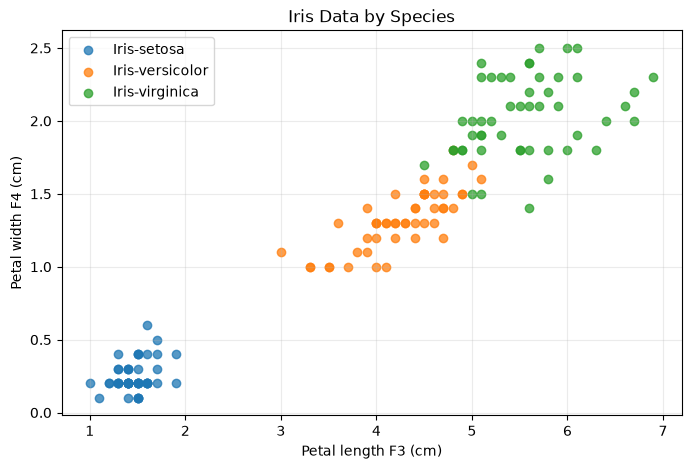

In [5]:
class_names = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]
class_colors = ["tab:blue", "tab:orange", "tab:green"]

plt.figure(figsize=(8, 5))

for class_name, class_color in zip(class_names, class_colors):
    class_rows = iris_df[iris_df["label"] == class_name]
    plt.scatter(
        class_rows["F3"],
        class_rows["F4"],
        label=class_name,
        color=class_color,
        alpha=0.75,
    )

plt.xlabel("Petal length F3 (cm)")
plt.ylabel("Petal width F4 (cm)")
plt.title("Iris Data by Species")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 3. 실습 단계

### 3.1 입력 특성과 목표값 분리하기

- 입력 `X`: `F1~F4` 네 개 열
- 목표값 `y`: `label` 한 개 열

문자열 정답은 `CrossEntropyLoss()`에 바로 넣을 수 없으므로 클래스 번호로 변환합니다.

| 클래스 번호 | 품종 |
|---:|---|
| 0 | Iris-setosa(아이리스 세토사) |
| 1 | Iris-versicolor(아이리스 버시컬러) |
| 2 | Iris-virginica(아이리스 버지니카) |

In [6]:
feature_columns = ["F1", "F2", "F3", "F4"]
label_column = "label"

label_to_index = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2,
}
index_to_label = {index: label for label, index in label_to_index.items()}

X = iris_df[feature_columns].to_numpy(dtype=np.float32)
y = iris_df[label_column].map(label_to_index).to_numpy(dtype=np.int64)

if np.isnan(X).any():
    raise ValueError("입력 특성에 결측값이 있습니다.")
if pd.isna(y).any():
    raise ValueError("정의되지 않은 품종명이 있습니다.")

print("입력 X 형상:", X.shape)
print("목표값 y 형상:", y.shape)
print("클래스 번호 예시:", y[:10])

입력 X 형상: (150, 4)
목표값 y 형상: (150,)
클래스 번호 예시: [0 0 0 0 0 0 0 0 0 0]


### 3.2 클래스 비율을 유지해 훈련·테스트 데이터 나누기

Stratified Split(스트래티파이드 스플릿, 계층적 분할)은 각 클래스 비율을 훈련 세트와 테스트 세트에 비슷하게 유지합니다.

이 실습에서는 각 품종 50개를 다음과 같이 나눕니다.

- 훈련 데이터: 품종별 40개, 총 120개
- 테스트 데이터: 품종별 10개, 총 30개

테스트 데이터는 학습에 사용하지 않고 최종 일반화 성능을 확인할 때만 사용합니다.

In [7]:
def stratified_train_test_indices(labels, test_ratio=0.2, seed=42):
    # 클래스별로 인덱스를 섞은 뒤 같은 비율로 테스트 인덱스를 선택합니다.
    random_generator = np.random.default_rng(seed)
    train_indices = []
    test_indices = []

    for class_index in np.unique(labels):
        class_indices = np.where(labels == class_index)[0]
        random_generator.shuffle(class_indices)

        number_of_test_samples = int(round(len(class_indices) * test_ratio))
        test_indices.extend(class_indices[:number_of_test_samples])
        train_indices.extend(class_indices[number_of_test_samples:])

    random_generator.shuffle(train_indices)
    random_generator.shuffle(test_indices)

    return np.array(train_indices), np.array(test_indices)


train_indices, test_indices = stratified_train_test_indices(
    y,
    test_ratio=0.2,
    seed=RANDOM_SEED,
)

X_train_raw = X[train_indices]
X_test_raw = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

print("훈련 데이터:", X_train_raw.shape, y_train.shape)
print("테스트 데이터:", X_test_raw.shape, y_test.shape)
print("훈련 클래스 개수:", np.bincount(y_train))
print("테스트 클래스 개수:", np.bincount(y_test))

훈련 데이터: (120, 4) (120,)
테스트 데이터: (30, 4) (30,)
훈련 클래스 개수: [40 40 40]
테스트 클래스 개수: [10 10 10]


### 3.3 훈련 데이터 기준으로 표준화하기

Standardization(스탠더다이제이션, 표준화)은 각 특성을 평균 0, 표준편차 1에 가까운 값으로 바꿉니다.

표준화된 값의 계산 흐름:

`표준화 값 → (원래 값 - 훈련 평균) / 훈련 표준편차`

중요한 원칙:

- 평균과 표준편차는 훈련 데이터에서만 계산합니다.
- 테스트 데이터에는 훈련 평균과 훈련 표준편차를 그대로 적용합니다.
- 테스트 데이터의 정보를 미리 사용하지 않아 Data Leakage(데이터 리키지, 데이터 누출)를 방지합니다.

In [8]:
train_mean = X_train_raw.mean(axis=0)
train_std = X_train_raw.std(axis=0)

# 표준편차가 0이면 나눗셈 오류가 발생하므로 확인합니다.
if np.any(train_std == 0):
    raise ValueError("표준편차가 0인 입력 특성이 있습니다.")

X_train = (X_train_raw - train_mean) / train_std
X_test = (X_test_raw - train_mean) / train_std

print("훈련 데이터의 원래 평균:", np.round(train_mean, 3))
print("훈련 데이터의 원래 표준편차:", np.round(train_std, 3))
print("표준화 후 훈련 평균:", np.round(X_train.mean(axis=0), 3))
print("표준화 후 훈련 표준편차:", np.round(X_train.std(axis=0), 3))

훈련 데이터의 원래 평균: [5.843 3.072 3.757 1.202]
훈련 데이터의 원래 표준편차: [0.831 0.434 1.767 0.769]
표준화 후 훈련 평균: [-0. -0. -0.  0.]
표준화 후 훈련 표준편차: [1. 1. 1. 1.]


### 3.4 NumPy 배열을 PyTorch 텐서로 변환하기

- 입력 특성: `torch.float32`
- 클래스 번호: `torch.long`

`CrossEntropyLoss()`의 정답은 원핫 벡터가 아니라 클래스 번호이며, 자료형은 `torch.long`이어야 합니다.

In [9]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train:", y_train_tensor.shape, y_train_tensor.dtype)
print("X_test :", X_test_tensor.shape, X_test_tensor.dtype)
print("y_test :", y_test_tensor.shape, y_test_tensor.dtype)

X_train: torch.Size([120, 4]) torch.float32
y_train: torch.Size([120]) torch.int64
X_test : torch.Size([30, 4]) torch.float32
y_test : torch.Size([30]) torch.int64


### 3.5 다중분류 모델 정의하기

모델 구조:

`입력 특성 4개 → nn.Linear(4, 3) → 클래스별 로짓 3개`

학습 중에는 모델 끝에 `Softmax()`를 추가하지 않습니다.

- `CrossEntropyLoss()`가 내부에서 LogSoftmax(로그 소프트맥스)와 NLLLoss(엔엘엘 로스, 음의 로그우도 손실)를 함께 처리합니다.
- 모델의 로짓을 `CrossEntropyLoss()`에 직접 전달하는 방식이 수치적으로 안정적입니다.
- 품종별 확률이 필요할 때만 평가 단계에서 `torch.softmax()`를 적용합니다.

In [10]:
class IrisSoftmaxModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(4, 3)

    def forward(self, input_features):
        # 소프트맥스를 적용하지 않은 클래스별 로짓을 반환합니다.
        return self.linear(input_features)


model = IrisSoftmaxModel()
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

print(model)
print("가중치 형상:", model.linear.weight.shape)
print("편향 형상:", model.linear.bias.shape)

IrisSoftmaxModel(
  (linear): Linear(in_features=4, out_features=3, bias=True)
)
가중치 형상: torch.Size([3, 4])
편향 형상: torch.Size([3])


### 3.6 학습 전 로짓과 확률 확인하기

- 로짓: 클래스별 원점수이므로 합이 1일 필요가 없습니다.
- 확률: 로짓에 소프트맥스를 적용한 값이며 한 데이터의 세 확률 합은 1입니다.
- 예측 클래스: 가장 큰 로짓 또는 가장 큰 확률의 인덱스입니다.

In [11]:
model.eval()

with torch.no_grad():
    sample_logits = model(X_train_tensor[:3])
    sample_probabilities = torch.softmax(sample_logits, dim=1)
    sample_predictions = torch.argmax(sample_logits, dim=1)

print("학습 전 로짓:")
print(sample_logits)
print("\n학습 전 확률:")
print(sample_probabilities)
print("\n확률의 행별 합:")
print(sample_probabilities.sum(dim=1))
print("\n학습 전 예측 클래스:", sample_predictions.tolist())

학습 전 로짓:
tensor([[ 1.6547, -0.0974,  1.9959],
        [-0.7969,  0.0215,  0.1714],
        [-1.3619,  0.0593, -0.5333]])

학습 전 확률:
tensor([[0.3876, 0.0672, 0.5452],
        [0.1695, 0.3842, 0.4463],
        [0.1345, 0.5573, 0.3081]])

확률의 행별 합:
tensor([1., 1., 1.])

학습 전 예측 클래스: [2, 2, 1]


### 3.7 모델 학습하기

한 Epoch(에폭, 전체 훈련 데이터 1회 학습)의 순서:

1. `optimizer.zero_grad()` → 이전 기울기 초기화
2. `model(X_train_tensor)` → 로짓 계산
3. `loss_function(logits, y_train_tensor)` → 손실 계산
4. `loss.backward()` → 기울기 계산
5. `optimizer.step()` → 가중치와 편향 갱신

훈련 데이터가 작으므로 전체 120개를 한 번에 학습하는 Full Batch(풀 배치, 전체 묶음 학습)를 사용합니다.

In [12]:
number_of_epochs = 1000
training_loss_history = []
training_accuracy_history = []

for epoch in range(1, number_of_epochs + 1):
    model.train()

    optimizer.zero_grad()
    train_logits = model(X_train_tensor)
    train_loss = loss_function(train_logits, y_train_tensor)
    train_loss.backward()
    optimizer.step()

    with torch.no_grad():
        train_predictions = torch.argmax(train_logits, dim=1)
        train_accuracy = (
            train_predictions == y_train_tensor
        ).float().mean().item()

    training_loss_history.append(train_loss.item())
    training_accuracy_history.append(train_accuracy)

    if epoch == 1 or epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Loss {train_loss.item():.4f} | "
            f"Accuracy {train_accuracy:.4f}"
        )

Epoch    1 | Loss 1.1081 | Accuracy 0.3083
Epoch  100 | Loss 0.4087 | Accuracy 0.8417
Epoch  200 | Loss 0.3313 | Accuracy 0.8750
Epoch  300 | Loss 0.2900 | Accuracy 0.9083
Epoch  400 | Loss 0.2612 | Accuracy 0.9167
Epoch  500 | Loss 0.2390 | Accuracy 0.9250
Epoch  600 | Loss 0.2213 | Accuracy 0.9333
Epoch  700 | Loss 0.2067 | Accuracy 0.9417
Epoch  800 | Loss 0.1944 | Accuracy 0.9417
Epoch  900 | Loss 0.1841 | Accuracy 0.9500
Epoch 1000 | Loss 0.1751 | Accuracy 0.9500


### 3.8 학습 과정 시각화하기

- Loss(로스, 손실)가 감소하면 모델의 예측과 정답 차이가 줄어든 것입니다.
- Accuracy(애큐러시, 정확도)가 증가하면 맞힌 데이터의 비율이 높아진 것입니다.
- 훈련 정확도만으로 일반화 성능을 판단하지 않습니다. 최종 판단은 학습에 사용하지 않은 테스트 데이터로 수행합니다.

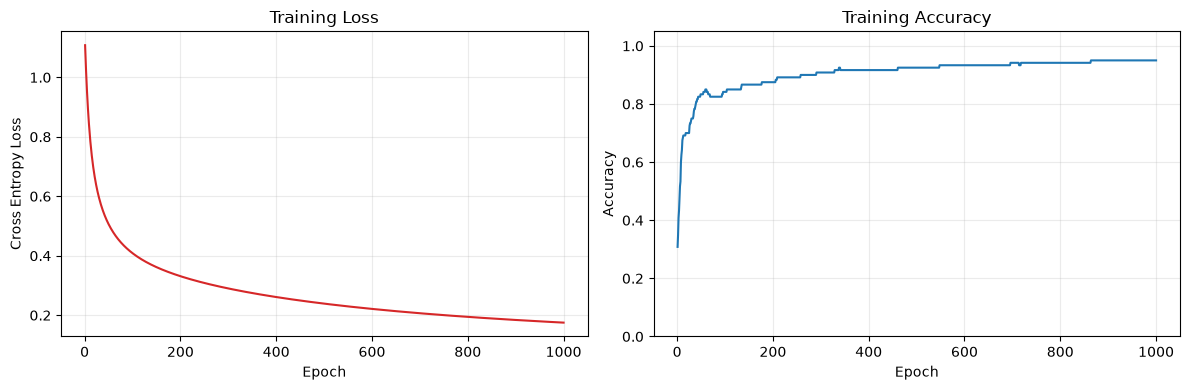

In [13]:
epoch_numbers = np.arange(1, number_of_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epoch_numbers, training_loss_history, color="tab:red")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross Entropy Loss")
axes[0].grid(alpha=0.25)

axes[1].plot(epoch_numbers, training_accuracy_history, color="tab:blue")
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 4. 결과 확인

### 4.1 훈련 데이터와 테스트 데이터 평가하기

평가 단계에서는 `model.eval()`과 `torch.no_grad()`를 사용합니다.

- `model.eval()`: 모델을 평가 모드로 전환
- `torch.no_grad()`: 기울기 계산을 중단해 메모리와 계산량 절약
- `torch.softmax(logits, dim=1)`: 클래스별 확률 계산
- `torch.argmax(logits, dim=1)`: 가장 큰 로짓의 클래스 선택

In [14]:
model.eval()

with torch.no_grad():
    final_train_logits = model(X_train_tensor)
    final_test_logits = model(X_test_tensor)

    final_train_loss = loss_function(final_train_logits, y_train_tensor).item()
    final_test_loss = loss_function(final_test_logits, y_test_tensor).item()

    train_probabilities = torch.softmax(final_train_logits, dim=1)
    test_probabilities = torch.softmax(final_test_logits, dim=1)

    final_train_predictions = torch.argmax(final_train_logits, dim=1)
    final_test_predictions = torch.argmax(final_test_logits, dim=1)

    final_train_accuracy = (
        final_train_predictions == y_train_tensor
    ).float().mean().item()
    final_test_accuracy = (
        final_test_predictions == y_test_tensor
    ).float().mean().item()

print(f"훈련 손실: {final_train_loss:.4f}")
print(f"테스트 손실: {final_test_loss:.4f}")
print(f"훈련 정확도: {final_train_accuracy:.4f}")
print(f"테스트 정확도: {final_test_accuracy:.4f}")

훈련 손실: 0.1750
테스트 손실: 0.1879
훈련 정확도: 0.9500
테스트 정확도: 0.9667


### 4.2 다중분류 혼동행렬 계산하기

Confusion Matrix(컨퓨전 매트릭스, 혼동행렬)는 실제 클래스와 예측 클래스의 관계를 보여 줍니다.

- 행: 실제 품종
- 열: 예측 품종
- 대각선: 올바르게 분류한 개수
- 대각선 밖: 다른 품종으로 잘못 분류한 개수

In [15]:
def calculate_confusion_matrix(targets, predictions, number_of_classes):
    matrix = np.zeros(
        (number_of_classes, number_of_classes),
        dtype=np.int64,
    )

    for actual_class, predicted_class in zip(targets, predictions):
        matrix[actual_class, predicted_class] += 1

    return matrix


y_test_array = y_test_tensor.numpy()
test_prediction_array = final_test_predictions.numpy()

confusion_matrix = calculate_confusion_matrix(
    y_test_array,
    test_prediction_array,
    number_of_classes=3,
)

print("테스트 혼동행렬:")
print(confusion_matrix)

테스트 혼동행렬:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


### 4.3 혼동행렬 시각화하기

숫자만 출력한 혼동행렬을 색상과 함께 확인합니다. 어떤 두 품종을 자주 혼동하는지 쉽게 파악할 수 있습니다.

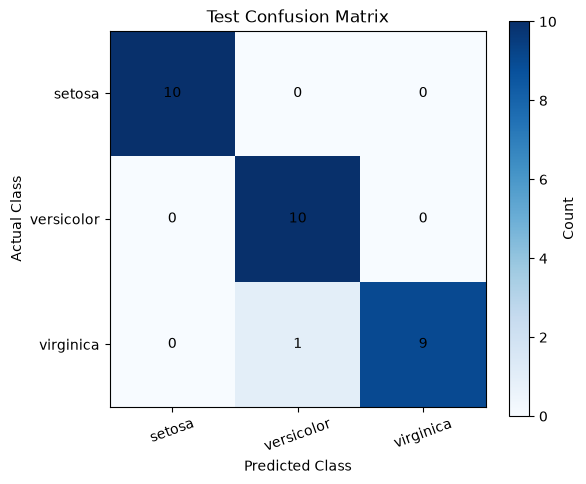

In [16]:
short_class_names = ["setosa", "versicolor", "virginica"]

plt.figure(figsize=(6, 5))
plt.imshow(confusion_matrix, cmap="Blues")
plt.colorbar(label="Count")

plt.xticks(range(3), short_class_names, rotation=20)
plt.yticks(range(3), short_class_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Test Confusion Matrix")

for row_index in range(3):
    for column_index in range(3):
        plt.text(
            column_index,
            row_index,
            confusion_matrix[row_index, column_index],
            ha="center",
            va="center",
            color="black",
        )

plt.tight_layout()
plt.show()

### 4.4 클래스별 평가지표 계산하기

한 클래스를 기준으로 해당 클래스와 나머지 클래스를 구분하여 계산합니다.

- Precision(프리시전, 정밀도): 해당 품종이라고 예측한 것 중 실제로 맞은 비율
- Recall(리콜, 재현율): 실제 해당 품종 중 모델이 찾아낸 비율
- F1 Score(에프원 스코어): 정밀도와 재현율의 조화평균
- Macro Average(매크로 애버리지, 단순 클래스 평균): 각 클래스 지표를 동일한 비중으로 평균

In [17]:
def calculate_multiclass_metrics(matrix):
    metric_rows = []

    for class_index in range(len(matrix)):
        true_positive = matrix[class_index, class_index]
        false_positive = matrix[:, class_index].sum() - true_positive
        false_negative = matrix[class_index, :].sum() - true_positive

        precision_denominator = true_positive + false_positive
        recall_denominator = true_positive + false_negative

        precision = (
            true_positive / precision_denominator
            if precision_denominator > 0
            else 0.0
        )
        recall = (
            true_positive / recall_denominator
            if recall_denominator > 0
            else 0.0
        )
        f1_score = (
            2 * precision * recall / (precision + recall)
            if precision + recall > 0
            else 0.0
        )

        metric_rows.append(
            {
                "class": short_class_names[class_index],
                "precision": precision,
                "recall": recall,
                "f1_score": f1_score,
                "support": int(matrix[class_index, :].sum()),
            }
        )

    return pd.DataFrame(metric_rows)


class_metrics_df = calculate_multiclass_metrics(confusion_matrix)

print("클래스별 평가 결과:")
print(class_metrics_df.round(4))

print("\nMacro Average:")
print(class_metrics_df[["precision", "recall", "f1_score"]].mean().round(4))

클래스별 평가 결과:
        class  precision  recall  f1_score  support
0      setosa     1.0000     1.0    1.0000       10
1  versicolor     0.9091     1.0    0.9524       10
2   virginica     1.0000     0.9    0.9474       10

Macro Average:
precision    0.9697
recall       0.9667
f1_score     0.9666
dtype: float64


### 4.5 실제 품종·예측 품종·확률 비교하기

정확도만 보지 않고 각 테스트 데이터의 예측 결과를 확인합니다.

- 실제 품종
- 예측 품종
- 세 품종별 확률
- 예측 성공 여부

확률이 서로 비슷하면 모델이 두 품종 사이에서 확신하지 못했다는 뜻입니다.

In [18]:
test_probability_array = test_probabilities.numpy()

prediction_result_df = pd.DataFrame(
    {
        "actual": [index_to_label[index] for index in y_test_array],
        "predicted": [
            index_to_label[index] for index in test_prediction_array
        ],
        "P_setosa": test_probability_array[:, 0],
        "P_versicolor": test_probability_array[:, 1],
        "P_virginica": test_probability_array[:, 2],
    }
)
prediction_result_df["correct"] = (
    prediction_result_df["actual"] == prediction_result_df["predicted"]
)

print(prediction_result_df.round(4).to_string(index=False))

         actual       predicted  P_setosa  P_versicolor  P_virginica  correct
Iris-versicolor Iris-versicolor    0.0130        0.8252       0.1618     True
 Iris-virginica  Iris-virginica    0.0003        0.2983       0.7015     True
Iris-versicolor Iris-versicolor    0.0152        0.6714       0.3134     True
    Iris-setosa     Iris-setosa    0.9542        0.0458       0.0000     True
 Iris-virginica  Iris-virginica    0.0001        0.2025       0.7975     True
 Iris-virginica  Iris-virginica    0.0000        0.1114       0.8885     True
    Iris-setosa     Iris-setosa    0.9278        0.0721       0.0000     True
    Iris-setosa     Iris-setosa    0.9958        0.0042       0.0000     True
 Iris-virginica  Iris-virginica    0.0001        0.0693       0.9306     True
 Iris-virginica  Iris-virginica    0.0001        0.0342       0.9657     True
    Iris-setosa     Iris-setosa    0.9855        0.0145       0.0000     True
Iris-versicolor Iris-versicolor    0.1399        0.8387       0.

### 4.6 잘못 분류한 데이터 확인하기

오분류 데이터의 원래 특성값과 클래스별 확률을 함께 확인하면 모델이 어려워한 사례를 찾을 수 있습니다.

Setosa(세토사)는 다른 두 품종과 꽃잎 크기 차이가 커서 비교적 쉽게 구분됩니다. Versicolor(버시컬러)와 Virginica(버지니카)는 특성 영역이 일부 겹쳐 오분류가 발생할 수 있습니다.

In [19]:
misclassified_mask = test_prediction_array != y_test_array

misclassified_df = pd.DataFrame(
    X_test_raw[misclassified_mask],
    columns=feature_columns,
)
misclassified_df["actual"] = [
    index_to_label[index] for index in y_test_array[misclassified_mask]
]
misclassified_df["predicted"] = [
    index_to_label[index]
    for index in test_prediction_array[misclassified_mask]
]

if len(misclassified_df) == 0:
    print("잘못 분류한 테스트 데이터가 없습니다.")
else:
    print("잘못 분류한 테스트 데이터:")
    print(misclassified_df.to_string(index=False))

잘못 분류한 테스트 데이터:
 F1  F2  F3  F4         actual       predicted
4.9 2.5 4.5 1.7 Iris-virginica Iris-versicolor


### 4.7 새로운 붓꽃 데이터 예측하기

새 데이터도 훈련 데이터의 평균과 표준편차로 표준화한 뒤 모델에 입력해야 합니다.

입력 순서:

`[꽃받침 길이 F1, 꽃받침 너비 F2, 꽃잎 길이 F3, 꽃잎 너비 F4]`

단위는 모두 cm입니다.

In [20]:
new_flowers = np.array(
    [
        [5.0, 3.4, 1.5, 0.2],
        [6.0, 2.8, 4.5, 1.4],
        [6.7, 3.1, 5.6, 2.4],
    ],
    dtype=np.float32,
)

# 반드시 훈련 데이터에서 계산한 평균과 표준편차를 사용합니다.
new_flowers_standardized = (new_flowers - train_mean) / train_std
new_flowers_tensor = torch.tensor(
    new_flowers_standardized,
    dtype=torch.float32,
)

model.eval()

with torch.no_grad():
    new_logits = model(new_flowers_tensor)
    new_probabilities = torch.softmax(new_logits, dim=1)
    new_predictions = torch.argmax(new_logits, dim=1)

for flower, probability, prediction in zip(
    new_flowers,
    new_probabilities.numpy(),
    new_predictions.numpy(),
):
    print("입력:", flower)
    print("예측 품종:", index_to_label[int(prediction)])
    print("클래스별 확률:", np.round(probability, 4))
    print("-" * 50)

입력: [5.  3.4 1.5 0.2]
예측 품종: Iris-setosa
클래스별 확률: [0.9853 0.0147 0.    ]
--------------------------------------------------
입력: [6.  2.8 4.5 1.4]
예측 품종: Iris-versicolor
클래스별 확률: [0.0126 0.7453 0.2422]
--------------------------------------------------
입력: [6.7 3.1 5.6 2.4]
예측 품종: Iris-virginica
클래스별 확률: [1.000e-04 3.400e-02 9.659e-01]
--------------------------------------------------


## 5. 핵심 정리

### 이번 실습에서 새로 배운 내용

- 실제 CSV 파일의 열, 앞 5행, 마지막 5행을 먼저 확인
- 문자열 품종을 클래스 번호 `0·1·2`로 변환
- 계층적 분할로 훈련 120개와 테스트 30개의 클래스 비율을 유지
- 훈련 데이터의 평균과 표준편차만 사용해 데이터 누출을 방지
- `nn.Linear(4, 3)`의 로짓을 `CrossEntropyLoss()`에 직접 전달
- 소프트맥스는 학습 모델 내부가 아니라 확률을 확인하는 평가 단계에서 적용
- 정확도뿐 아니라 혼동행렬과 클래스별 정밀도·재현율·F1 점수를 확인
- 새 데이터에도 훈련 데이터의 표준화 기준을 그대로 적용

### Lab 06_1과 Lab 06_2의 연결

| 구분 | Lab 06_1 | Lab 06_2 |
|---|---|---|
| 데이터 | 코드에 직접 입력한 작은 데이터 | 실제 Iris CSV |
| 목적 | 다중분류 원리 이해 | 실제 데이터 적용과 일반화 평가 |
| 입력 | 4개 특성 | 4개 꽃 크기 특성 |
| 출력 | 3개 클래스 | 3개 붓꽃 품종 |
| 손실함수 | `CrossEntropyLoss()` | `CrossEntropyLoss()` |
| 평가 | 학습 데이터 중심 | 훈련·테스트 분리 평가 |


## 6. 실행 확인

아래 조건을 확인하면 실습이 정상적으로 완료된 것입니다.

- [ ] `iris.csv`의 형상이 `(150, 5)`로 출력됩니다.
- [ ] 품종별 데이터가 각각 50개로 출력됩니다.
- [ ] 훈련 데이터는 120개, 테스트 데이터는 30개입니다.
- [ ] 표준화 후 훈련 특성의 평균은 0, 표준편차는 1에 가깝습니다.
- [ ] 학습 손실이 초기값보다 감소합니다.
- [ ] 테스트 예측 확률의 각 행 합은 1입니다.
- [ ] 혼동행렬 전체 합은 테스트 데이터 개수 30과 같습니다.
- [ ] 실제 품종·예측 품종·클래스별 확률이 출력됩니다.

In [21]:
assert iris_df.shape == (150, 5)
assert set(iris_df.columns) == {"F1", "F2", "F3", "F4", "label"}
assert len(X_train_tensor) == 120
assert len(X_test_tensor) == 30
assert np.allclose(X_train.mean(axis=0), 0.0, atol=1e-6)
assert np.allclose(X_train.std(axis=0), 1.0, atol=1e-6)
assert np.allclose(
    test_probabilities.sum(dim=1).numpy(),
    1.0,
    atol=1e-6,
)
assert confusion_matrix.sum() == len(y_test)

print("모든 핵심 실행 검증을 통과했습니다.")

AssertionError: 